## Polynominal logistic regression, SVM, Logistic regression 

#### Importing all libraries

In [212]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    precision_score, 
    recall_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

#### Reading dataset

In [213]:
df = (pd
      .read_csv('2d-2class-dataset-2.csv')  # generaited data from https://notmatthancock.github.io/software/dataset2d/
      .rename(columns={'# x': 'feature 1', 
                       'y'  : 'feature 2'}
      )
)
X = df.drop('label', axis=1)
y = df['label']

#### Ploting data

<Axes: xlabel='feature 1', ylabel='feature 2'>

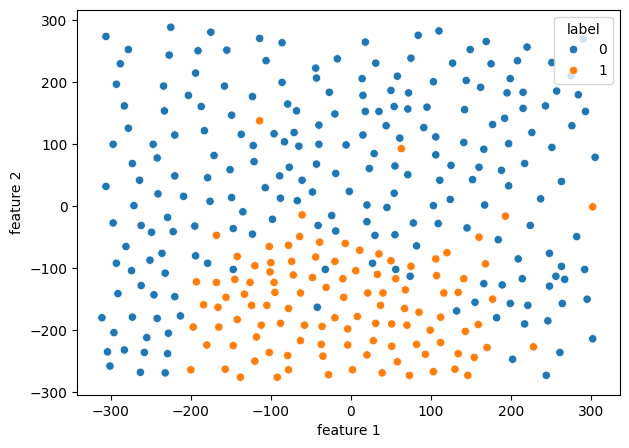

In [214]:
fig, axs = plt.subplots(figsize=(7, 5), dpi=100)
sns.scatterplot(x=X['feature 1'], y=X['feature 2'], hue=y, ax=axs)


Ploting distribution of data

<Axes: ylabel='count'>

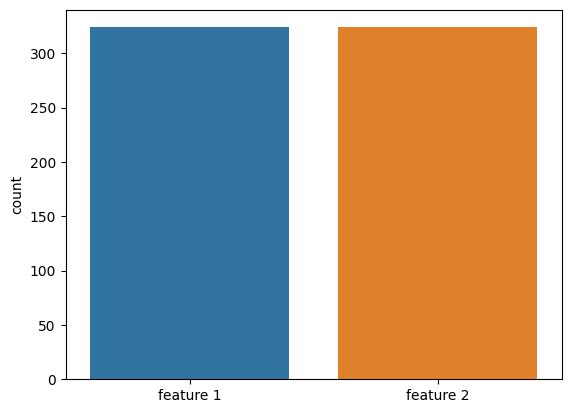

In [215]:
sns.countplot(X)

#### Scaling and spliting data

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

#### Train and predict

In [217]:
logreg_poly = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('model', LogisticRegression(C=1))
    ]
)

svm_nonlinear = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', gamma=1, C=2))
    ]
)

logreg_poly.fit(X_train, y_train)
svm_nonlinear.fit(X_train, y_train)

pred_logreg_poly = logreg_poly.predict(X_test)
pred_svm_nonlinear = svm_nonlinear.predict(X_test)

#### Metrics

In [218]:
def metrics_table(y_true, y_pred):
    rows = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    return pd.DataFrame(
        {"metric": list(rows.keys()), "value": list(rows.values())}
    )

In [219]:
metrics = pd.concat(
    [
        metrics_table(y_test, pred_logreg_poly).assign(model="LogisticReg with poly"),
        metrics_table(y_test, pred_svm_nonlinear).assign(model="SVM")
    ],  ignore_index=True
)
metrics.pivot(index="metric", columns="model", values="value")

model,LogisticReg with poly,SVM
metric,,
accuracy,0.925926,0.950617
f1,0.875000,0.916667
precision,0.913043,0.956522
recall,0.840000,0.880000


#### Plot cat-line

/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


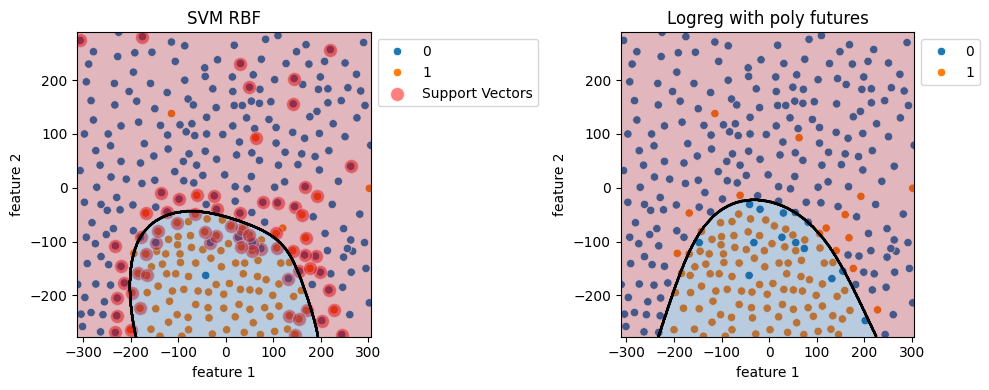

In [220]:
h = 1
x_min, x_max = X['feature 1'].min() - 1, X['feature 1'].max() + 1
y_min, y_max = X['feature 2'].min() - 1, X['feature 2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

log = logreg_poly.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
svm = svm_nonlinear.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

scaler_step = svm_nonlinear.named_steps['scaler']
sv = scaler_step.inverse_transform(svm_nonlinear.named_steps['model'].support_vectors_) # supports vectors


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

sns.scatterplot(x=X['feature 1'], y=X['feature 2'], hue=y, ax=axs[0])
sns.scatterplot(x=sv[:, 0], y=sv[:, 1], color='red', s=100, ax=axs[0], markers='o', alpha=0.5, label='Support Vectors')
axs[0].contourf(xx, yy, svm, alpha=0.3, cmap='RdBu')
axs[0].contour(xx, yy, svm, colors='k')
axs[0].set_title('SVM RBF')
axs[0].legend(bbox_to_anchor=(1, 1))


sns.scatterplot(x=X['feature 1'], y=X['feature 2'], hue=y, ax=axs[1])
axs[1].contourf(xx, yy, log, alpha=0.3, cmap='RdBu')
axs[1].contour(xx, yy, log, colors='k')
axs[1].set_title('Logreg with poly futures')
axs[1].legend(bbox_to_anchor=(1, 1))

fig.tight_layout()

#### Plot confusion matrix

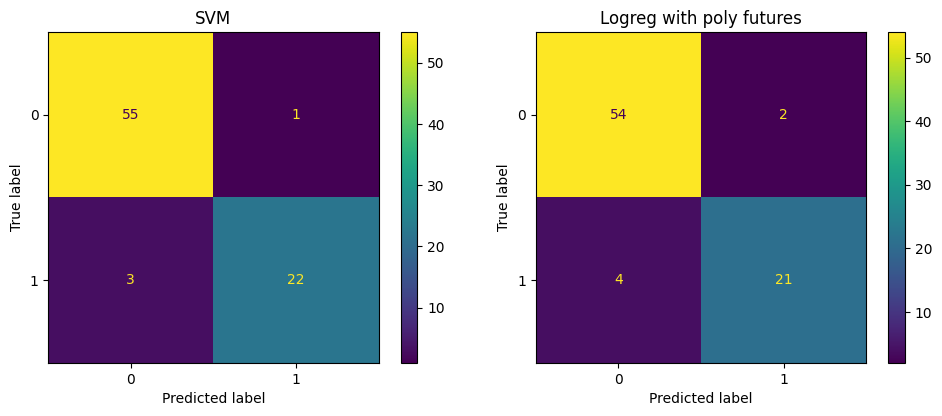

In [221]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, pred_svm_nonlinear, ax=axs[0])
axs[0].set_title('SVM')

ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg_poly, ax=axs[1])
axs[1].set_title('Logreg with poly futures')

fig.tight_layout()

#### Cross validation

In [222]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)

cross_val_logreg_poly = cross_validate(
        logreg_poly,
        X,
        y,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}
)
cross_val_svm_nonlinear = cross_validate(
        svm_nonlinear,
        X_train,
        y_train,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"} 
)


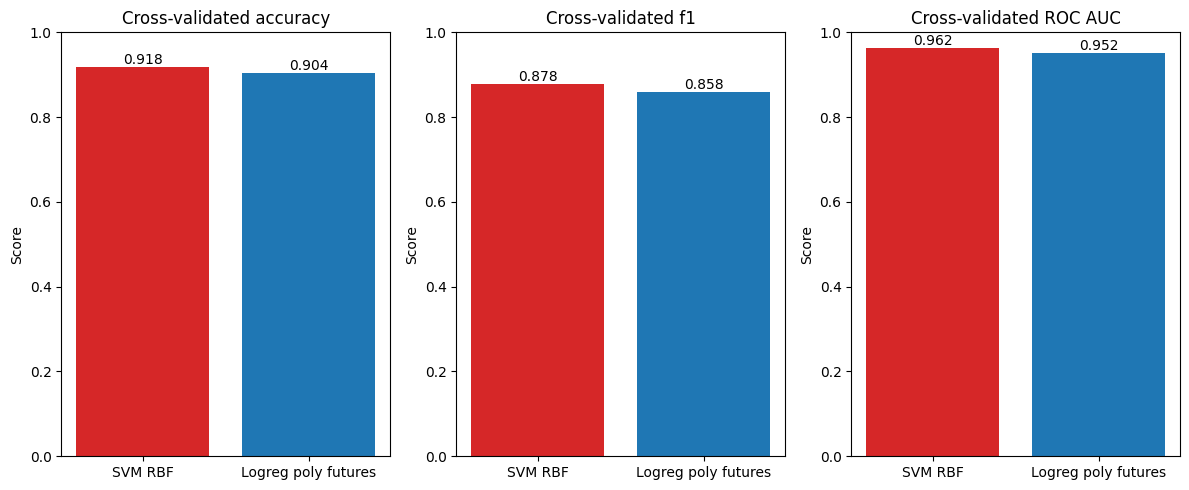

In [223]:
from sklearn.model_selection import cross_validate

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

models = ['SVM RBF', 'Logreg poly futures']
test_accuracy = [cross_val_svm_nonlinear['test_accuracy'].mean(), cross_val_logreg_poly['test_accuracy'].mean()]
test_f1 = [cross_val_svm_nonlinear['test_f1'].mean(), cross_val_logreg_poly['test_f1'].mean()]
test_roc_auc = [cross_val_svm_nonlinear['test_roc_auc'].mean(), cross_val_logreg_poly['test_roc_auc'].mean()]

bar_colors = ['tab:red', 'tab:blue']

bars_0 = axs[0].bar(models, test_accuracy, color=bar_colors)
axs[0].bar(models, test_accuracy, color=bar_colors)
axs[0].set_ylabel('Score')
axs[0].set_title('Cross-validated accuracy')
axs[0].bar_label(bars_0, fmt='%.3f') 
axs[0].set_ylim(0, 1)

bars_1 = axs[1].bar(models, test_f1, color=bar_colors)
axs[1].bar(models, test_f1, color=bar_colors)
axs[1].set_ylabel('Score')
axs[1].set_title('Cross-validated f1')
axs[1].bar_label(bars_1, fmt='%.3f') 
axs[1].set_ylim(0, 1)

bars_2 = axs[2].bar(models, test_roc_auc, color=bar_colors)
axs[2].bar(models, test_roc_auc, color=bar_colors)
axs[2].set_ylabel('Score')
axs[2].set_title('Cross-validated ROC AUC')
axs[2].bar_label(bars_2, fmt='%.3f') 
axs[2].set_ylim(0, 1)

fig.tight_layout()


## Logistic regresion with GridSearch (breast canser dataset)

#### Dataset spliting and model

In [224]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV

X, y = load_breast_cancer(return_X_y=True)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y, test_size=0.25, random_state=20)

logreg_grid = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model' , LogisticRegression())

        ]
    ),
    param_grid=[
        {
            "model__solver": ["lbfgs"],
            "model__l1_ratio": [0.0],
            "model__C": [0.01, 0.1, 1.0, 10.0],
        },
        {
            "model__solver": ["liblinear"],
            "model__l1_ratio": [0.0, 1.0],
            "model__C": [0.01, 0.1, 1.0, 10.0],
        },
    ],
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)


#### Training

In [225]:
logreg_grid.fit(X_train_b, y_train_b)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0.0], 'model__solver': ['lbfgs']}, {'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0.0, 1.0], 'model__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verb

#### Best params

In [226]:
logreg_results = pd.DataFrame(logreg_grid.cv_results_)[
    [
        "param_model__solver",
        "param_model__l1_ratio",
        "param_model__C",
        "mean_test_score",
        "rank_test_score",
    ]
].copy()

logreg_results.sort_values(['rank_test_score', 'param_model__C'])

,param_model__solver,param_model__l1_ratio,param_model__C,mean_test_score,rank_test_score
6,liblinear,0.0,0.10,0.993668,1
1,lbfgs,0.0,0.10,0.993429,2
9,liblinear,1.0,1.00,0.993309,3
2,lbfgs,0.0,1.00,0.992234,4
8,liblinear,0.0,1.00,0.992234,4
0,lbfgs,0.0,0.01,0.991159,6
4,liblinear,0.0,0.01,0.990920,7
7,liblinear,1.0,0.10,0.990442,8
3,lbfgs,0.0,10.00,0.989247,9
10,liblinear,0.0,10.00,0.989247,9


#### Training model with best params and predicting (solver=liblinear, C=0.10)

In [227]:
logreg_b = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model' , LogisticRegression(solver='lbfgs', C=1))

    ]
)
logreg_b.fit(X_train_b, y_train_b)

pred_logreg_b = logreg_b.predict(X_test_b)
pred_logreg_b_score = logreg_b.decision_function(X_test_b)

#### Metrics table

In [228]:
metrics_b = metrics_table(y_test_b, pred_logreg_b).assign(model="Logreg with best parameters")
metrics_b.pivot(index="metric", columns="model", values="value")

model,Logreg with best parameters
metric,
accuracy,0.986014
f1,0.988506
precision,0.977273
recall,1.000000


#### Confusion matrix

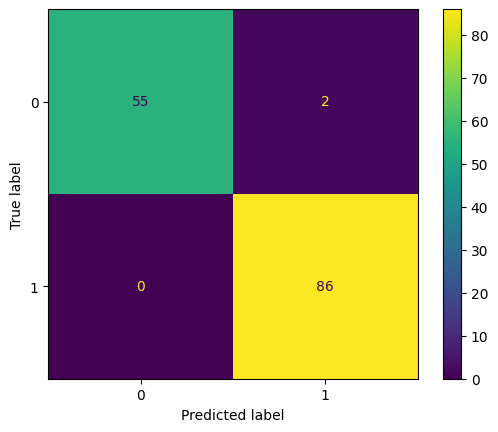

In [229]:
ConfusionMatrixDisplay.from_predictions(y_test_b, pred_logreg_b)

#### Presicion x Recall, RocCurve

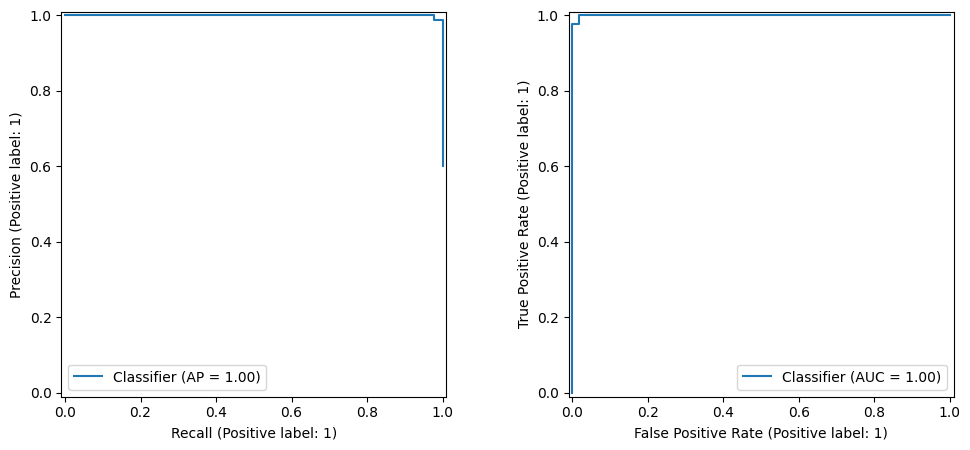

In [230]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

PrecisionRecallDisplay.from_predictions(y_test_b, pred_logreg_b_score, ax=axs[0])
RocCurveDisplay.from_predictions(y_test_b, pred_logreg_b_score, ax=axs[1])